In [1]:
# Core
import pandas as pd
import numpy as np

In [2]:
# Text Processing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [3]:
# Visualization
!pip install wordcloud
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [4]:
# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [6]:
from google.colab import drive
drive.mount('/content/drive')

training_reviews_df = pd.read_csv('/content/drive/MyDrive/moviereviewdataset/train_movie_review.csv')
validation_reviews_df = pd.read_csv('/content/drive/MyDrive/moviereviewdataset/val_movie_review.csv')
testing_reviews_df = pd.read_csv('/content/drive/MyDrive/moviereviewdataset/test_movie_review.csv')

print(training_reviews_df.head())
print(training_reviews_df.info())

Mounted at /content/drive
   Unnamed: 0                                             review  sentiment
0        3774  Having avoided seeing the movie in the cinema,...          0
1       48396  With this movie I was really hoping that the i...          0
2        1980  Raymond Burr stars as an attorney caught up in...          0
3        6703  A lot people get hung up on this films tag as ...          1
4       28168  I was a fan of Buffy and hoped it would come t...          0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  35000 non-null  int64 
 1   review      35000 non-null  object
 2   sentiment   35000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 820.4+ KB
None


In [7]:
print("Train shape:", training_reviews_df.shape)
print("Validation shape:", validation_reviews_df.shape)
print("Test shape:", testing_reviews_df.shape)

print("\nTrain sentiment distribution:")
print(training_reviews_df['sentiment'].value_counts())

print("\nValidation sentiment distribution:")
print(validation_reviews_df['sentiment'].value_counts())

print("\nTest sentiment distribution:")
print(testing_reviews_df['sentiment'].value_counts())

Train shape: (35000, 3)
Validation shape: (5000, 3)
Test shape: (10000, 3)

Train sentiment distribution:
sentiment
0    17584
1    17416
Name: count, dtype: int64

Validation sentiment distribution:
sentiment
1    2545
0    2455
Name: count, dtype: int64

Test sentiment distribution:
sentiment
1    5039
0    4961
Name: count, dtype: int64


In [8]:
for df in [training_reviews_df, validation_reviews_df, testing_reviews_df]:
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)

In [9]:
print("Train missing values:")
print(training_reviews_df.isnull().sum())

print("\nValidation missing values:")
print(validation_reviews_df.isnull().sum())

print("\nTest missing values:")
print(testing_reviews_df.isnull().sum())

Train missing values:
review       0
sentiment    0
dtype: int64

Validation missing values:
review       0
sentiment    0
dtype: int64

Test missing values:
review       0
sentiment    0
dtype: int64


In [10]:
training_reviews_df = training_reviews_df.dropna(subset=['review', 'sentiment'])
validation_reviews_df = validation_reviews_df.dropna(subset=['review', 'sentiment'])
testing_reviews_df = testing_reviews_df.dropna(subset=['review', 'sentiment'])

In [11]:
training_reviews_df['sentiment'] = training_reviews_df['sentiment'].astype(int)
validation_reviews_df['sentiment'] = validation_reviews_df['sentiment'].astype(int)
testing_reviews_df['sentiment'] = testing_reviews_df['sentiment'].astype(int)

In [12]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [13]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)

    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

In [14]:
training_reviews_df['cleaned_review'] = training_reviews_df['review'].apply(clean_text)
validation_reviews_df['cleaned_review'] = validation_reviews_df['review'].apply(clean_text)
testing_reviews_df['cleaned_review'] = testing_reviews_df['review'].apply(clean_text)

training_reviews_df[['review', 'cleaned_review', 'sentiment']].head()

,review,cleaned_review,sentiment
0,"Having avoided seeing the movie in the cinema,...",avoided seeing movie cinema buying dvd wife xm...,0
1,With this movie I was really hoping that the i...,movie really hoping idea make hashed together ...,0
2,Raymond Burr stars as an attorney caught up in...,raymond burr star attorney caught murder best ...,0
3,A lot people get hung up on this films tag as ...,lot people get hung film tag childrens film ce...,1
4,I was a fan of Buffy and hoped it would come t...,fan buffy hoped would come proper end angel go...,0


In [15]:
vocabulary_limit = 10000

text_tokenizer = Tokenizer(num_words=vocabulary_limit, oov_token="<OOV>")
text_tokenizer.fit_on_texts(training_reviews_df['cleaned_review'])

In [16]:
train_review_sequences = text_tokenizer.texts_to_sequences(training_reviews_df['cleaned_review'])
validation_review_sequences = text_tokenizer.texts_to_sequences(validation_reviews_df['cleaned_review'])
test_review_sequences = text_tokenizer.texts_to_sequences(testing_reviews_df['cleaned_review'])

In [17]:
print(training_reviews_df['cleaned_review'].iloc[0])
print(train_review_sequences[0][:20])

avoided seeing movie cinema buying dvd wife xmas watch expect much usually mean get bargained mamma mia utter utter cr like abba like song old lp film terrible stage show look like bit musical race along song hurriedly following one another characterisation dance number heavily choreographed according extra dvd thrown away half body ever screen dance chorus north european appear small greek island set set number would disgraced cliff richards musical sixtiesmeryl see im actingstreep cant even make usual mugging effective overthetop musical grand piece winner take meryl met note director shot stillness camera gradually showing distance growing streep brosnan singing awful karaoke amateur night camera cannot stop moving like bad mtv one never settle enjoy music enthusiasm character even worse botched piece excre become highest grossing film uk best selling dvd boot blair campbell new labour really reduced uk zombie critical faculty anyone
[3957, 212, 2, 330, 2455, 171, 219, 1, 34, 398, 1

In [18]:
from wordcloud import WordCloud, STOPWORDS

custom_stopwords = set(STOPWORDS)

custom_stopwords.update([
    "one","get","got","go","make","really","still","even",
    "also","would","could","film","movie","movies"
])

In [19]:
text = " ".join(training_reviews_df['cleaned_review'])

In [21]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=custom_stopwords,
    max_words=100,
    colormap='viridis',
    contour_color='black',
    contour_width=1
).generate(text)

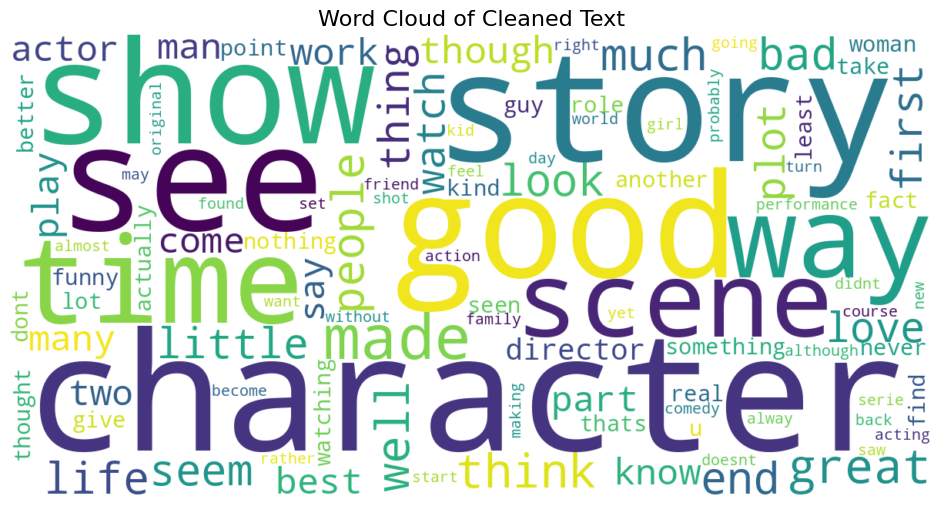

In [22]:
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Cleaned Text", fontsize=16)
plt.show()

In [23]:
review_sequence_lengths = [len(seq) for seq in train_review_sequences]

sequence_max_length = int(np.percentile(review_sequence_lengths, 95))

print("95th percentile sequence length:", sequence_max_length)

95th percentile sequence length: 305


In [24]:
train_padded_reviews = pad_sequences(train_review_sequences, maxlen=sequence_max_length, padding='post', truncating='post')
validation_padded_reviews = pad_sequences(validation_review_sequences, maxlen=sequence_max_length, padding='post', truncating='post')
test_padded_reviews = pad_sequences(test_review_sequences, maxlen=sequence_max_length, padding='post', truncating='post')

In [25]:
train_sentiments = training_reviews_df['sentiment'].values
validation_sentiments = validation_reviews_df['sentiment'].values
test_sentiments = testing_reviews_df['sentiment'].values

In [26]:
print("X_train shape:", train_padded_reviews.shape)
print("X_val shape:", validation_padded_reviews.shape)
print("X_test shape:", test_padded_reviews.shape)

print("y_train shape:", train_sentiments.shape)
print("y_val shape:", validation_sentiments.shape)
print("y_test shape:", test_sentiments.shape)

X_train shape: (35000, 305)
X_val shape: (5000, 305)
X_test shape: (10000, 305)
y_train shape: (35000,)
y_val shape: (5000,)
y_test shape: (10000,)


In [27]:
#Model 1 Simple RNN (Baseline)
vocabulary_size = 10000
embedding_vector_size = 128

In [28]:
basic_rnn_model = Sequential()

basic_rnn_model.add(Embedding(
    input_dim=vocabulary_size,
    output_dim=embedding_vector_size,
    input_length=sequence_max_length
))

basic_rnn_model.add(SimpleRNN(64))

basic_rnn_model.add(Dropout(0.5))

basic_rnn_model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [29]:
basic_rnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [30]:
basic_rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
rnn_stop_callback = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [32]:
basic_rnn_history = basic_rnn_model.fit(
    train_padded_reviews,
    train_sentiments,
    validation_data=(validation_padded_reviews, validation_sentiments),
    epochs=10,
    batch_size=64,
    callbacks=[rnn_stop_callback]
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 80s 142ms/step - accuracy: 0.5042 - loss: 0.6989 - val_accuracy: 0.4954 - val_loss: 0.6931
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 80s 147ms/step - accuracy: 0.5195 - loss: 0.6882 - val_accuracy: 0.4898 - val_loss: 0.6931
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 75s 137ms/step - accuracy: 0.5263 - loss: 0.6847 - val_accuracy: 0.5030 - val_loss: 0.6942
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 75s 137ms/step - accuracy: 0.5224 - loss: 0.7081 - val_accuracy: 0.4956 - val_loss: 0.6933


In [33]:
basic_rnn_loss, basic_rnn_accuracy = basic_rnn_model.evaluate(test_padded_reviews, test_sentiments)

print("Simple RNN Test Loss:", basic_rnn_loss)
print("Simple RNN Test Accuracy:", basic_rnn_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.5035 - loss: 0.6929
Simple RNN Test Loss: 0.6928985714912415
Simple RNN Test Accuracy: 0.5034999847412109


In [34]:
basic_rnn_probabilities = basic_rnn_model.predict(test_padded_reviews)
basic_rnn_predictions = (basic_rnn_probabilities > 0.5).astype("int32")

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step


In [35]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(test_sentiments, basic_rnn_predictions))

              precision    recall  f1-score   support

           0       0.50      0.93      0.65      4961
           1       0.55      0.09      0.15      5039

    accuracy                           0.50     10000
   macro avg       0.52      0.51      0.40     10000
weighted avg       0.52      0.50      0.40     10000



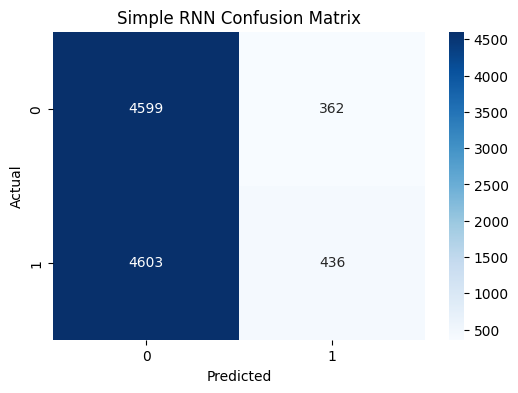

In [36]:
basic_rnn_cm = confusion_matrix(test_sentiments, basic_rnn_predictions)

plt.figure(figsize=(6,4))
sns.heatmap(basic_rnn_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Simple RNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

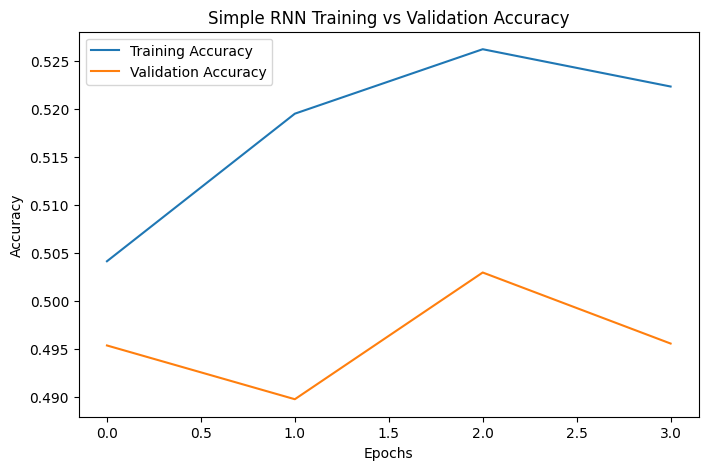

In [37]:
plt.figure(figsize=(8,5))
plt.plot(basic_rnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(basic_rnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Simple RNN Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

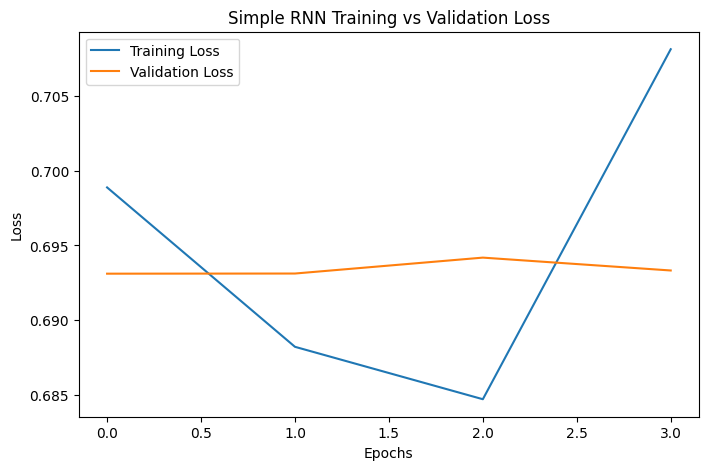

In [38]:
plt.figure(figsize=(8,5))
plt.plot(basic_rnn_history.history['loss'], label='Training Loss')
plt.plot(basic_rnn_history.history['val_loss'], label='Validation Loss')
plt.title("Simple RNN Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [39]:
#Model 2 LSTM
standard_lstm_model = Sequential()

standard_lstm_model.add(Embedding(
    input_dim=vocabulary_size,
    output_dim=128,
    input_length=sequence_max_length
))

standard_lstm_model.add(LSTM(64))

standard_lstm_model.add(Dropout(0.5))

standard_lstm_model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [40]:
standard_lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [41]:
standard_lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [42]:
lstm_stop_callback = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [43]:
standard_lstm_history = standard_lstm_model.fit(
    train_padded_reviews,
    train_sentiments,
    validation_data=(validation_padded_reviews, validation_sentiments),
    epochs=10,
    batch_size=64,
    callbacks=[lstm_stop_callback]
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 217s 390ms/step - accuracy: 0.5052 - loss: 0.6936 - val_accuracy: 0.5090 - val_loss: 0.6934
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 215s 393ms/step - accuracy: 0.5130 - loss: 0.6893 - val_accuracy: 0.4996 - val_loss: 0.6923
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 213s 389ms/step - accuracy: 0.5250 - loss: 0.6733 - val_accuracy: 0.5018 - val_loss: 0.6954
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 266s 398ms/step - accuracy: 0.5265 - loss: 0.6619 - val_accuracy: 0.5014 - val_loss: 0.7143
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 263s 399ms/step - accuracy: 0.7108 - loss: 0.5364 - val_accuracy: 0.8370 - val_loss: 0.3911
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 261s 397ms/step - accuracy: 0.8828 - loss: 0.3011 - val_accuracy: 0.8752 - val_loss: 0.3093
Epoch 7/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 212s 387ms/step - accuracy: 0.9258 - loss: 0.2108 - val_accuracy: 0.8736 - val_loss: 0.3192
Epoch 8/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 217s 396ms/step - accuracy: 0.9503 -

In [44]:
standard_lstm_model = Sequential()

standard_lstm_model.add(Embedding(
    input_dim=vocabulary_size,
    output_dim=128,
    input_length=sequence_max_length,
    mask_zero=True
))

standard_lstm_model.add(LSTM(64))
standard_lstm_model.add(Dropout(0.5))
standard_lstm_model.add(Dense(1, activation='sigmoid'))

standard_lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

standard_lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [45]:
lstm_stop_callback = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

standard_lstm_history = standard_lstm_model.fit(
    train_padded_reviews,
    train_sentiments,
    validation_data=(validation_padded_reviews, validation_sentiments),
    epochs=10,
    batch_size=64,
    callbacks=[lstm_stop_callback]
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 262s 471ms/step - accuracy: 0.8336 - loss: 0.3852 - val_accuracy: 0.8716 - val_loss: 0.3040
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 262s 478ms/step - accuracy: 0.9067 - loss: 0.2459 - val_accuracy: 0.8702 - val_loss: 0.3041
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 276s 505ms/step - accuracy: 0.9291 - loss: 0.1885 - val_accuracy: 0.8750 - val_loss: 0.3193
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 269s 491ms/step - accuracy: 0.9470 - loss: 0.1463 - val_accuracy: 0.8700 - val_loss: 0.4182


In [46]:
standard_lstm_loss, standard_lstm_accuracy = standard_lstm_model.evaluate(test_padded_reviews, test_sentiments)
print("LSTM Accuracy:", standard_lstm_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.8790 - loss: 0.2951
LSTM Accuracy: 0.8790000081062317


In [47]:
standard_lstm_probabilities = standard_lstm_model.predict(test_padded_reviews)
standard_lstm_predictions = (standard_lstm_probabilities > 0.5).astype("int32")

standard_lstm_cm = confusion_matrix(test_sentiments, standard_lstm_predictions)

313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step


In [48]:
#Improvised LSTM
from tensorflow.keras.layers import Bidirectional
bidirectional_lstm_model = Sequential()

bidirectional_lstm_model.add(Embedding(
    input_dim=vocabulary_size,
    output_dim=128,
    input_length=sequence_max_length,
    mask_zero=True
))

bidirectional_lstm_model.add(Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3)))

bidirectional_lstm_model.add(Dense(64, activation='relu'))
bidirectional_lstm_model.add(Dropout(0.5))

bidirectional_lstm_model.add(Dense(1, activation='sigmoid'))

bidirectional_lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [49]:
bilstm_stop_callback = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

bilstm_history = bidirectional_lstm_model.fit(
    train_padded_reviews,
    train_sentiments,
    validation_data=(validation_padded_reviews, validation_sentiments),
    epochs=8,
    batch_size=64,
    callbacks=[bilstm_stop_callback]
)

Epoch 1/8
547/547 ━━━━━━━━━━━━━━━━━━━━ 684s 1s/step - accuracy: 0.8213 - loss: 0.3989 - val_accuracy: 0.8740 - val_loss: 0.3314
Epoch 2/8
547/547 ━━━━━━━━━━━━━━━━━━━━ 666s 1s/step - accuracy: 0.8983 - loss: 0.2632 - val_accuracy: 0.8722 - val_loss: 0.3026
Epoch 3/8
547/547 ━━━━━━━━━━━━━━━━━━━━ 669s 1s/step - accuracy: 0.9206 - loss: 0.2129 - val_accuracy: 0.8664 - val_loss: 0.3158
Epoch 4/8
547/547 ━━━━━━━━━━━━━━━━━━━━ 682s 1s/step - accuracy: 0.9381 - loss: 0.1663 - val_accuracy: 0.8614 - val_loss: 0.3482


In [50]:
!pip install gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 39.2 MB/s eta 0:00:00


In [51]:
!pip install numpy==1.23.5
!pip install gensim --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 66.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [52]:
import gensim
print(gensim.__version__)


4.4.0


In [54]:
from gensim.models import Word2Vec

tokenized_reviews = training_reviews_df['cleaned_review'].apply(lambda x: x.split()).tolist()

word2vec_embedding_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

In [56]:
embedding_vector_size = 100
review_word_index = text_tokenizer.word_index

word2vec_embedding_matrix = np.zeros((vocabulary_size, embedding_vector_size))

for word, i in review_word_index.items():
    if i < vocabulary_size and word in word2vec_embedding_model.wv:
        word2vec_embedding_matrix[i] = word2vec_embedding_model.wv[word]

In [57]:
word2vec_lstm_model = Sequential()

word2vec_lstm_model.add(Embedding(
    input_dim=vocabulary_size,
    output_dim=embedding_vector_size,
    weights=[word2vec_embedding_matrix],
    input_length=sequence_max_length,
    trainable=False,
    mask_zero=True
))

word2vec_lstm_model.add(LSTM(64))
word2vec_lstm_model.add(Dropout(0.5))
word2vec_lstm_model.add(Dense(1, activation='sigmoid'))

word2vec_lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

word2vec_lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [58]:
word2vec_stop_callback = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

word2vec_lstm_history = word2vec_lstm_model.fit(
    train_padded_reviews,
    train_sentiments,
    validation_data=(validation_padded_reviews, validation_sentiments),
    epochs=10,
    batch_size=64,
    callbacks=[word2vec_stop_callback]
)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 216s 379ms/step - accuracy: 0.8194 - loss: 0.4020 - val_accuracy: 0.8640 - val_loss: 0.3220
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 253s 363ms/step - accuracy: 0.8617 - loss: 0.3299 - val_accuracy: 0.8746 - val_loss: 0.2943
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 201s 367ms/step - accuracy: 0.8776 - loss: 0.2990 - val_accuracy: 0.8818 - val_loss: 0.2851
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 199s 363ms/step - accuracy: 0.8843 - loss: 0.2838 - val_accuracy: 0.8804 - val_loss: 0.2803
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 207s 373ms/step - accuracy: 0.8900 - loss: 0.2704 - val_accuracy: 0.8824 - val_loss: 0.2792
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 259s 366ms/step - accuracy: 0.8963 - loss: 0.2567 - val_accuracy: 0.8814 - val_loss: 0.2734
Epoch 7/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 196s 359ms/step - accuracy: 0.9017 - loss: 0.2458 - val_accuracy: 0.8848 - val_loss: 0.2716
Epoch 8/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 199s 363ms/step - accuracy: 0.9065 -

In [59]:
word2vec_lstm_loss, word2vec_lstm_accuracy = word2vec_lstm_model.evaluate(test_padded_reviews, test_sentiments)

print("Word2Vec LSTM Test Loss:", word2vec_lstm_loss)
print("Word2Vec LSTM Test Accuracy:", word2vec_lstm_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - accuracy: 0.8831 - loss: 0.2708
Word2Vec LSTM Test Loss: 0.27082669734954834
Word2Vec LSTM Test Accuracy: 0.8830999732017517


In [60]:
word2vec_probabilities = word2vec_lstm_model.predict(test_padded_reviews)
word2vec_predictions = (word2vec_probabilities > 0.5).astype("int32")

313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 75ms/step


In [61]:
print(classification_report(test_sentiments, word2vec_predictions))

              precision    recall  f1-score   support

           0       0.87      0.90      0.88      4961
           1       0.90      0.86      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



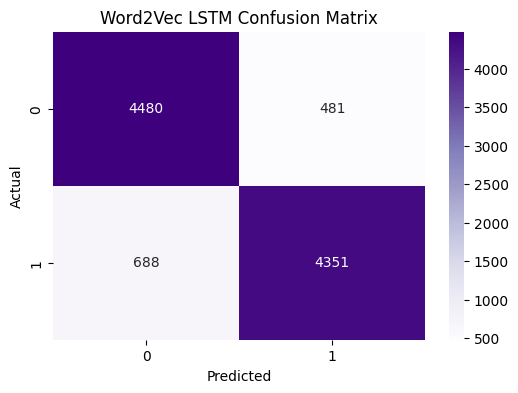

In [62]:
word2vec_cm = confusion_matrix(test_sentiments, word2vec_predictions)

plt.figure(figsize=(6,4))
sns.heatmap(word2vec_cm, annot=True, fmt='d', cmap='Purples')
plt.title("Word2Vec LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [63]:
#Comparison
results = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "Word2Vec LSTM"],
    "Accuracy": [basic_rnn_accuracy, standard_lstm_accuracy, word2vec_lstm_accuracy]
})

print(results)

           Model  Accuracy
0     Simple RNN    0.5035
1           LSTM    0.8790
2  Word2Vec LSTM    0.8831


In [64]:
wrong_prediction_indices = []

for i in range(len(test_sentiments)):
    if test_sentiments[i] != word2vec_predictions[i]:
        wrong_prediction_indices.append(i)

print("Total misclassified:", len(wrong_prediction_indices))

Total misclassified: 1169


In [67]:
misclassified = np.where(word2vec_predictions != test_sentiments)[0]

print("Total Misclassified Samples:", len(misclassified))

Total Misclassified Samples: 50013104


In [68]:
for i in misclassified[:3]:
    print("Review:")
    print(testing_reviews_df['review'].iloc[i])
    print("Actual:", test_sentiments[i])
    print("Predicted:", word2vec_predictions[i])
    print("-"*80)

Review:
I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok to have a huge fat man vs a strong man but I'm glad times have changed. It was a terrible main event just like every match Luger is in is terrible. Other matches on the card were Razor Ramon vs Ted Dibiase, Steiner Brothers vs Heavenly Bodies, Shawn Michaels vs Curt Hening, this was the event where Shawn named his big monster of a body guard Diesel, IRS vs 1-2-3 Kid, Bret Hart first takes on Doink then takes on Jerry Lawler and stuff with the Harts and Lawler was always very interesting, then Ludvig Borga destroyed Marty Jannetty, Undertaker took on Giant Gonzalez in another terrible match, The Smoking Gunns and Tatanka took on Bam Bam Bigelow and the Headshrinkers, and Yokozuna defe

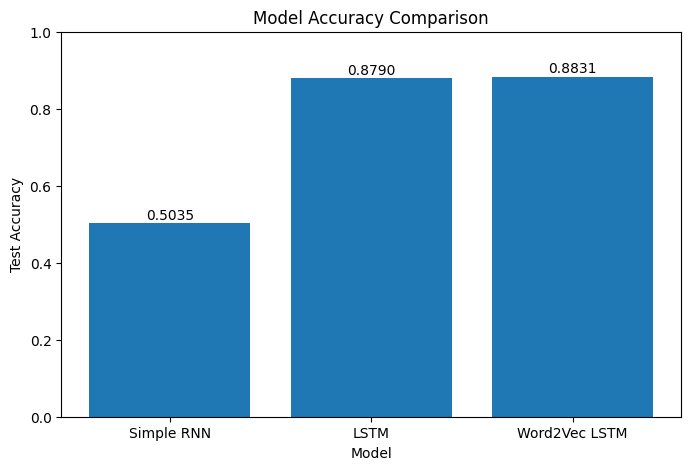

In [69]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)

for i, acc in enumerate(results["Accuracy"]):
    plt.text(i, acc + 0.01, f"{acc:.4f}", ha='center')

plt.show()

In [70]:
loss_results = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "Word2Vec LSTM"],
    "Loss": [basic_rnn_loss, standard_lstm_loss, word2vec_lstm_loss]
})

print(loss_results)

           Model      Loss
0     Simple RNN  0.692899
1           LSTM  0.295098
2  Word2Vec LSTM  0.270827


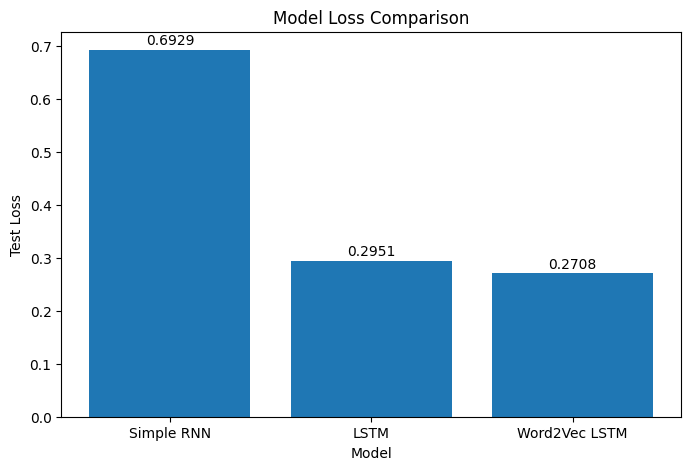

In [71]:
plt.figure(figsize=(8,5))
plt.bar(loss_results["Model"], loss_results["Loss"])
plt.title("Model Loss Comparison")
plt.xlabel("Model")
plt.ylabel("Test Loss")

for i, loss in enumerate(loss_results["Loss"]):
    plt.text(i, loss + 0.01, f"{loss:.4f}", ha='center')

plt.show()

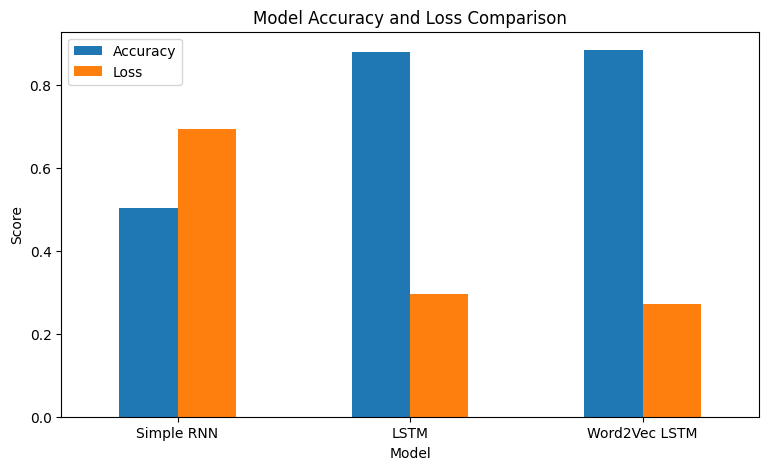

In [72]:
comparison_df = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "Word2Vec LSTM"],
    "Accuracy": [basic_rnn_accuracy, standard_lstm_accuracy, word2vec_lstm_accuracy],
    "Loss": [basic_rnn_loss, standard_lstm_loss, word2vec_lstm_loss]
})

comparison_df.plot(
    x="Model",
    y=["Accuracy", "Loss"],
    kind="bar",
    figsize=(9,5)
)

plt.title("Model Accuracy and Loss Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

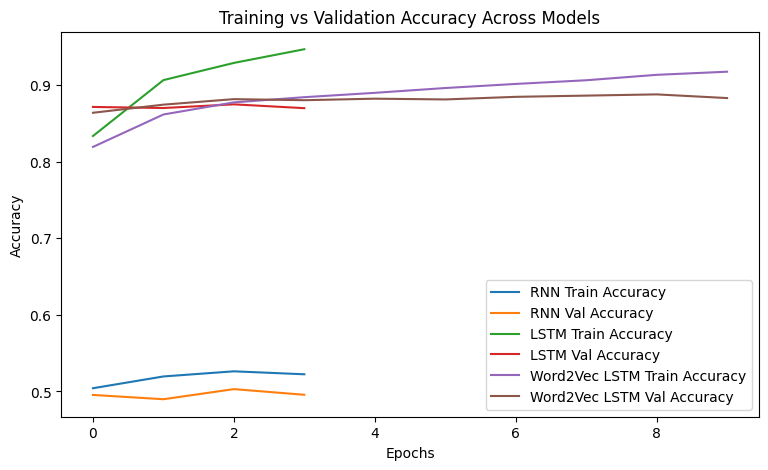

In [73]:
plt.figure(figsize=(9,5))

plt.plot(basic_rnn_history.history['accuracy'], label='RNN Train Accuracy')
plt.plot(basic_rnn_history.history['val_accuracy'], label='RNN Val Accuracy')

plt.plot(standard_lstm_history.history['accuracy'], label='LSTM Train Accuracy')
plt.plot(standard_lstm_history.history['val_accuracy'], label='LSTM Val Accuracy')

plt.plot(word2vec_lstm_history.history['accuracy'], label='Word2Vec LSTM Train Accuracy')
plt.plot(word2vec_lstm_history.history['val_accuracy'], label='Word2Vec LSTM Val Accuracy')

plt.title("Training vs Validation Accuracy Across Models")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

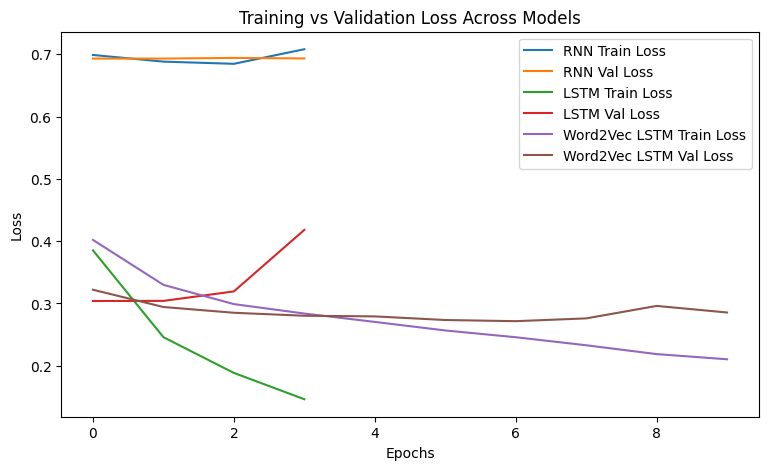

In [74]:
plt.figure(figsize=(9,5))

plt.plot(basic_rnn_history.history['loss'], label='RNN Train Loss')
plt.plot(basic_rnn_history.history['val_loss'], label='RNN Val Loss')

plt.plot(standard_lstm_history.history['loss'], label='LSTM Train Loss')
plt.plot(standard_lstm_history.history['val_loss'], label='LSTM Val Loss')

plt.plot(word2vec_lstm_history.history['loss'], label='Word2Vec LSTM Train Loss')
plt.plot(word2vec_lstm_history.history['val_loss'], label='Word2Vec LSTM Val Loss')

plt.title("Training vs Validation Loss Across Models")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

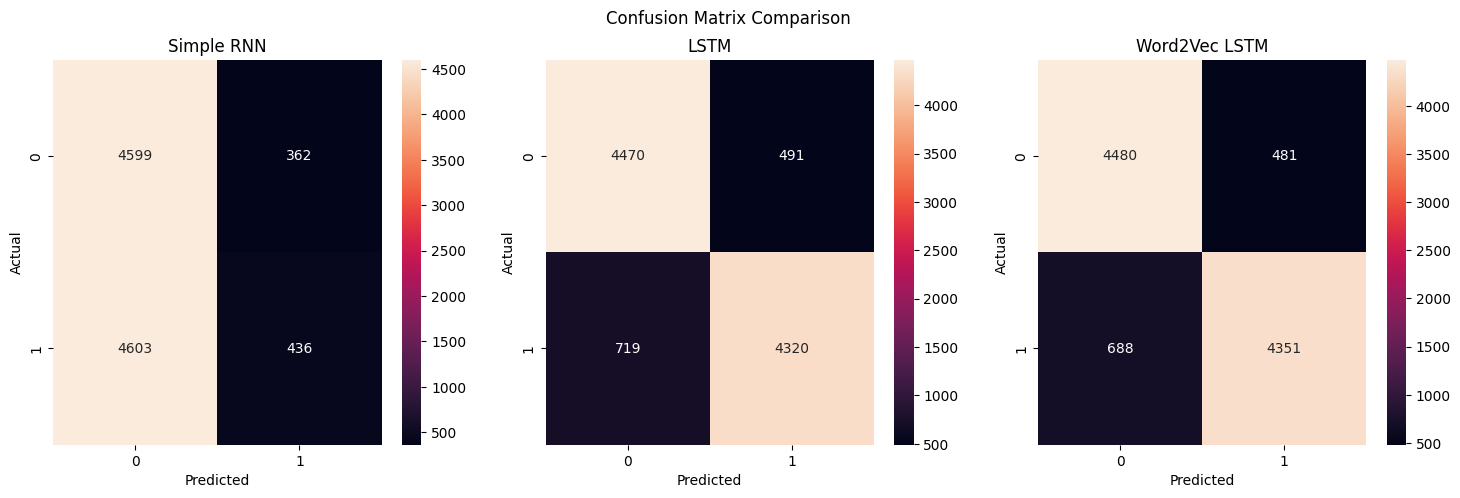

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.heatmap(basic_rnn_cm, annot=True, fmt='d', ax=axes[0])
axes[0].set_title("Simple RNN")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(standard_lstm_cm, annot=True, fmt='d', ax=axes[1])
axes[1].set_title("LSTM")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

sns.heatmap(word2vec_cm, annot=True, fmt='d', ax=axes[2])
axes[2].set_title("Word2Vec LSTM")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.suptitle("Confusion Matrix Comparison")
plt.show()

In [76]:
wrong_prediction_indices = []

for i in range(len(test_sentiments)):
    if test_sentiments[i] != word2vec_predictions[i]:
        wrong_prediction_indices.append(i)

print("Total misclassified:", len(wrong_prediction_indices))

Total misclassified: 1169


In [78]:
import re
from tensorflow.keras.preprocessing.sequence import pad_sequences

def preprocess_input(text):

    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    sequence = text_tokenizer.texts_to_sequences([text])

    padded_sequence = pad_sequences(
        sequence,
        maxlen=494,
        padding='post',
        truncating='post'
    )

    return padded_sequence

In [79]:
user_text = "This movie was bad and critical"

processed = preprocess_input(user_text)
prediction = word2vec_lstm_model.predict(processed)[0][0]

if prediction > 0.5:
    print("Positive")
else:
    print("Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 898ms/step
Negative


In [80]:
user_text = "This movie was amazing and emotional"

processed = preprocess_input(user_text)
prediction = word2vec_lstm_model.predict(processed)[0][0]

if prediction > 0.5:
    print("Positive")
else:
    print("Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Positive


In [81]:
import pickle

word2vec_lstm_model.save("sentiment_model.keras")

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(text_tokenizer, f)

with open("max_len.pkl", "wb") as f:
    pickle.dump(sequence_max_length, f)

In [82]:
code = """
import streamlit as st
import pickle
import re
import string
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download("stopwords")
nltk.download("wordnet")

st.set_page_config(
    page_title="Movie Review Sentiment Analysis",
    page_icon="",
    layout="centered"
)

@st.cache_resource
def load_resources():
    model = load_model("sentiment_model.keras")

    with open("tokenizer.pkl", "rb") as f:
        tokenizer = pickle.load(f)

    with open("max_len.pkl", "rb") as f:
        max_len = pickle.load(f)

    return model, tokenizer, max_len

model, tokenizer, max_len = load_resources()

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)

    words = text.split()
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

def predict_sentiment(review):
    cleaned = clean_text(review)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(
        sequence,
        maxlen=max_len,
        padding="post",
        truncating="post"
    )

    probability = model.predict(padded)[0][0]

    if probability >= 0.5:
        sentiment = "Positive"
        confidence = probability
    else:
        sentiment = "Negative"
        confidence = 1 - probability

    return sentiment, confidence, cleaned

st.title("Movie Review Sentiment Analysis")
st.write("Enter a movie review below and the trained Word2Vec LSTM model will classify it as positive or negative.")

review = st.text_area(
    "Movie Review",
    height=180,
    placeholder="Example: This movie was emotional, beautifully acted, and worth watching."
)

if st.button("Predict Sentiment"):
    if review.strip() == "":
        st.warning("Please enter a movie review first.")
    else:
        sentiment, confidence, cleaned_review = predict_sentiment(review)

        st.subheader("Prediction Result")

        if sentiment == "Positive":
            st.success(f"Sentiment: {sentiment}")
        else:
            st.error(f"Sentiment: {sentiment}")

        st.write(f"Confidence: {confidence:.2%}")

        with st.expander("View cleaned text"):
            st.write(cleaned_review)

st.markdown("---")
st.caption("Model used: LSTM with Word2Vec Embedding Layer")
"""

with open(r"D:\Herald\AI and ML\Coursework\Task3\app.py", "w") as f:
    f.write(code)

print("app.py created successfully!")

app.py created successfully!


<>:41: SyntaxWarning: invalid escape sequence '\S'
<>:41: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_15450/390904565.py:41: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub(r"http\S+|www\S+", "", text)


In [83]:
import pickle

word2vec_lstm_model.save(r"D:\Herald\AI and ML\Coursework\Task3\sentiment_model.keras")

with open(r"D:\Herald\AI and ML\Coursework\Task3\tokenizer.pkl", "wb") as f:
    pickle.dump(text_tokenizer, f)

with open(r"D:\Herald\AI and ML\Coursework\Task3\max_len.pkl", "wb") as f:
    pickle.dump(sequence_max_length, f)

print("Model, tokenizer, and max_len saved successfully.")

Model, tokenizer, and max_len saved successfully.
